In [3]:
from data.dataset import SingleAudioSpectrogramDataset
from config import (
    EXPORT_DATA_PATH,
    SAMPLING_RATE
)
from torch.utils.data import DataLoader
import torch
import torch
from pathlib import Path
import numpy as np
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM, FinerCAM
from models.cnn import CustomCNNModel
from models.vit import ViTModel
from config import SAMPLING_RATE, FIG_PATH
import librosa
import os

In [7]:
file_path = 'samples/loa_LmS_08;00_CHI_ph,dr_rt_tv.wav'

dataset = SingleAudioSpectrogramDataset(file_path, label=2, target_sample_rate=SAMPLING_RATE, root_dir=f"{EXPORT_DATA_PATH}/train")
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

X = next(iter(dataloader))

# plot the spectrogram
import matplotlib.pyplot as plt
librosa.display.specshow(X[0]['data'].numpy(), sr=SAMPLING_RATE, x_axis='s', y_axis='log')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Amplitude')
plt.show()

ZeroDivisionError: float division by zero

In [13]:
# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# RESHAPE TRANSFORM FOR ViT
# -----------------------------
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# -----------------------------
# LOAD MODEL
# -----------------------------
def load_trained_model(model_name: str, model_path: str, num_classes: int, modelstr='resnet18'):
    if model_name == "CustomCNNModel":
        model = CustomCNNModel(num_classes=num_classes, modelstr=modelstr)
    elif model_name == "ViTModel":
        model = ViTModel(num_classes=num_classes)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

# -----------------------------
# Single audio CAM visualization
# -----------------------------
def single_audio_cam_plot(
    model,
    audio_path: str,
    label: int,
    target_layers,
    model_name: str,
    n_fft=512,
    hop_length=256,
    power=2.0,
    normalize=True,
    transform=None,
    output_dir=FIG_PATH,
    save_fig=True
):
    dataset = SingleAudioSpectrogramDataset(
        file_path=audio_path,
        label=label,
        target_sample_rate=SAMPLING_RATE,
        n_fft=n_fft,
        hop_length=hop_length,
        power=power,
        root_dir=f"{EXPORT_DATA_PATH}/train",
        normalize=normalize,
        transform=transform
    )

    sample, true_label = dataset[0]
    waveform = sample['waveform']
    spectrogram = sample['data']
    sr = sample['sample_rate']

    input_tensor = spectrogram.unsqueeze(0).float().to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0, predicted_class].item()
    
    print(f"Predicted class: {predicted_class} (confidence: {confidence:.2f}), True label: {true_label}")

    # CAM methods
    cam_methods = {
        "GradCAM": GradCAM,
        "GradCAM++": GradCAMPlusPlus,
        "ScoreCAM": ScoreCAM,
        "FinerCAM": FinerCAM
    }

    if not Path(output_dir).exists():
        Path(output_dir).mkdir(parents=True, exist_ok=True)

    n_cols = 2 + len(cam_methods)  # waveform, spectrogram, CAMs
    fig, axs = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))

    # Ensure axs is always iterable
    if n_cols == 1:
        axs = [axs]

    # -----------------------
    # Column 0: waveform
    # -----------------------
    waveform_clean = waveform.squeeze().cpu().numpy()
    axs[0].set_title("Waveform", fontsize=14)
    librosa.display.waveshow(waveform_clean, sr=sr, ax=axs[0])
    axs[0].set_xlabel("Time (s)", fontsize=12)
    axs[0].set_ylabel("Amplitude", fontsize=12)

    # -----------------------
    # Column 1: spectrogram
    # -----------------------
    S = librosa.stft(waveform_clean, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    time_frames = np.arange(S_db.shape[1])
    time_seconds = librosa.frames_to_time(time_frames, sr=sr, hop_length=hop_length)
    extent = [time_seconds[0], time_seconds[-1], 0, S_db.shape[0]]

    axs[1].imshow(S_db, origin='lower', aspect='auto', cmap='viridis', extent=extent)
    axs[1].set_title(f"Original Spectrogram\nTrue: {true_label}", fontsize=14)
    axs[1].set_xlabel("Time (s)", fontsize=12)
    axs[1].set_ylabel("Frequency (bins)", fontsize=12)

    # -----------------------
    # Columns 2+: CAM overlays
    # -----------------------
    for col_idx, (method_name, CAMClass) in enumerate(cam_methods.items(), start=2):
        if model_name == "ViTModel":
            cam = CAMClass(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
        else:
            cam = CAMClass(model=model, target_layers=target_layers)

        targets = [ClassifierOutputTarget(true_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Resize CAM to match spectrogram
        if grayscale_cam.shape != S_db.shape:
            from scipy.ndimage import zoom
            scale_factors = (S_db.shape[0] / grayscale_cam.shape[0],
                             S_db.shape[1] / grayscale_cam.shape[1])
            grayscale_cam_resized = zoom(grayscale_cam, scale_factors, order=1)
        else:
            grayscale_cam_resized = grayscale_cam

        axs[col_idx].imshow(S_db, origin='lower', aspect='auto', cmap='viridis', extent=extent)
        axs[col_idx].imshow(grayscale_cam_resized, cmap='inferno', alpha=0.5, origin='lower', aspect='auto', extent=extent)
        axs[col_idx].set_title(f"{method_name}\nPred: {predicted_class} ({confidence:.2f})", fontsize=14)
        axs[col_idx].set_xlabel("Time (s)", fontsize=12)
        axs[col_idx].set_ylabel("Frequency (bins)", fontsize=12)

    plt.tight_layout()
    if save_fig:
        save_path = Path(output_dir) / f"{Path(audio_path).stem}_CAMs.png"
        plt.savefig(save_path, dpi=300)
        plt.close(fig)
        print(f"Saved CAM figure → {save_path}")
    else:
        plt.show()

    return predicted_class, confidence, true_label

In [14]:
model_path = "/net/projects/scratch/winter/valid_until_31_July_2026/ybrima/Models/ChimpSSL/best_model_experiment_resnet18_chimp_resnet18_exp_200.pth" #best_model_experiment_200.pth" #best_model_experiment_resnet18_chimp_resnet18_exp_200.pth"
model_name = "CustomCNNModel"  # or "ViTModel"
num_classes = 11  # Adjust based on your dataset
modelstr = 'resnet18'  # Specify the model architecture if using CustomCNNModel
model = load_trained_model(model_name, model_path, num_classes, modelstr=modelstr)


# make prediction 
X = next(iter(dataloader))
with torch.no_grad():
    outputs = model(X[0]['data'].float().to(device))
    probabilities = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted_class].item()

print(f"Predicted class: {predicted_class} (confidence: {confidence:.2f}), True label: {X[1].item()}")

Predicted class: 2 (confidence: 1.00), True label: 2


Predicted class: 2 (confidence: 1.00), True label: 2


OutOfMemoryError: CUDA out of memory. Tried to allocate 666.00 MiB. GPU 0 has a total capacity of 47.45 GiB of which 331.69 MiB is free. Process 1084689 has 45.25 GiB memory in use. Including non-PyTorch memory, this process has 1.84 GiB memory in use. Of the allocated memory 1.59 GiB is allocated by PyTorch, and 45.21 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

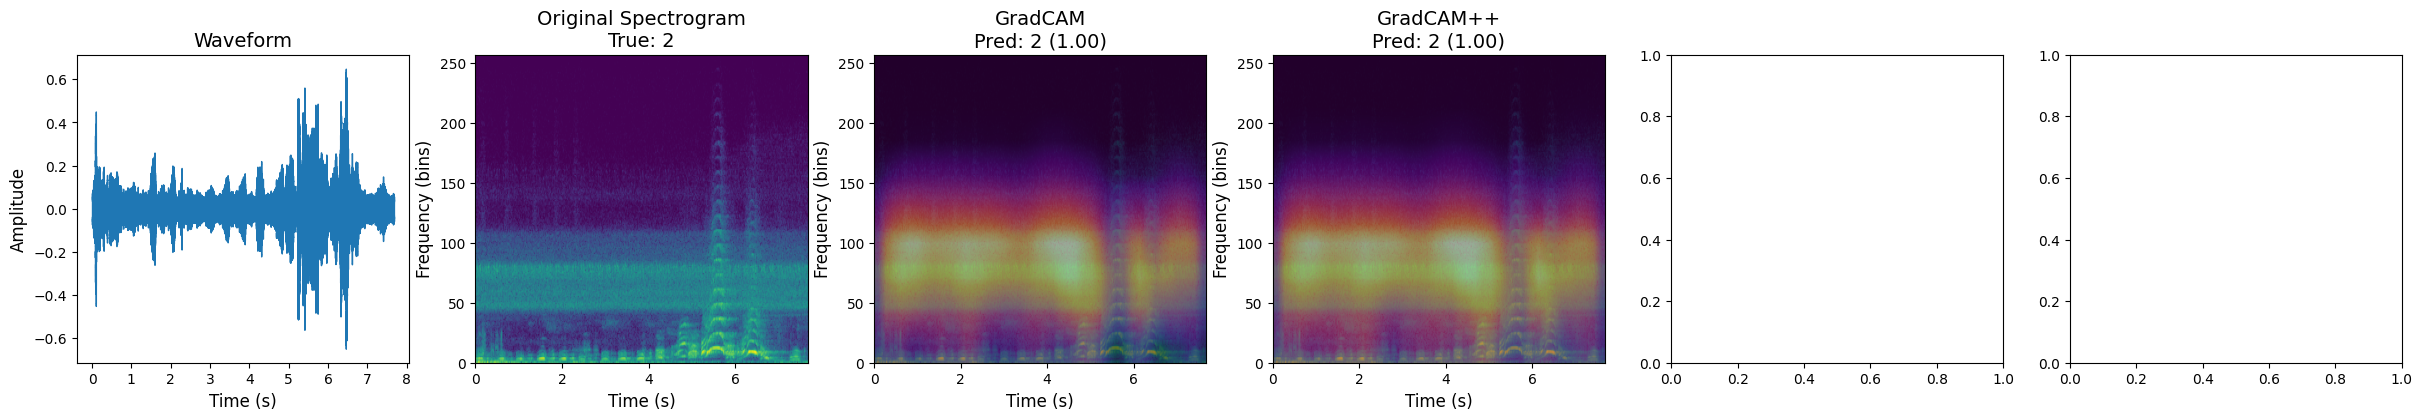

In [15]:
target_layers = [model.base_model.layer4[-1]]  # For CustomCNNModel with ResNet backbone
audio_path = file_path
true_label = X[1].item()

pred_class, conf, true_label = single_audio_cam_plot(
    model, audio_path, true_label, target_layers, model_name,save_fig=False
)